In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

Note: This notebook should be updated as I changed the autosomal workflow.

In [2]:
# Loading in the kuderna mutation data and new metadata

kuderna_data = pd.read_csv("../data/science.abn7829_data_s2.csv")
# I pick out the following columns
col_species_mut = ['SPECIES_BINOMIAL', 'GENUS', 'SPECIES', 'FAMILY', 'GENERATION_LENGTH', 'MU_PER_GENERATION',
       'MU_PER_YEAR', 'EFFECTIVE_POP_SIZE']
df_species_mut = kuderna_data[col_species_mut]

metadata_dir = "/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"
metadata_dirs = glob.glob(metadata_dir+"*_individuals.txt")

df_l = []
for d in metadata_dirs:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    df_l.append(dir_metadata)
all_inds = pd.concat(df_l)

In [16]:
all_inds

,BIOSAMPLE_ID,PDGP_ID,GVCF_ID,SRA_SAMPLE_ID,BIOPROJECT_ID,BAM_FOLDER,GVCF_FOLDER,REFERENCE_FOLDER,GENUS,SPECIES,...,REPORTED_SEX,GENETIC_SEX,AVG_COVERAGE_GW,PROP_COVERED_GW,AVG_COVERAGE_A,PROP_COVERED_A,AVG_COVERAGE_X,PROP_COVERED_X,AVG_COVERAGE_Y,PROP_COVERED_Y
0,SAMEA112483158,PD_0629,PD_0629,ERS14600509,PRJEB59576,Carlito_syrichta_ssp,Carlito_syrichta_ssp,Cephalopachus_bancanus_ssp,Carlito,syrichta,...,Unknown,Unknown,26.7228,0.9795,26.9096,0.9798,14.8478,0.9583,Unknown,Unknown
0,SAMEA112482833,PD_0040,PD_0040,ERS14600184,PRJEB59576,Lophocebus_aterrimus_ssp,Lophocebus_aterrimus_ssp,Papio_anubis_ssp,Lophocebus,aterrimus,...,M,M,33.6494,0.9846,34.5261,0.9860,17.7023,0.9629,27.2812,0.9245
1,SAMEA115292508,SAMEA115292508,SAMEA115292508,ERS18276634,PRJEB72259,Lophocebus_aterrimus_ssp,Lophocebus_aterrimus_ssp,Papio_anubis_ssp,Lophocebus,aterrimus,...,Unknown,M,32.5046,0.9850,33.3430,0.9864,17.3809,0.9633,24.1785,0.9249
2,SAMN23530509,SAMN23530509,SAMN23530509,SRS11219902,PRJNA785018,Lophocebus_aterrimus_ssp,Lophocebus_aterrimus_ssp,Papio_anubis_ssp,Lophocebus,aterrimus,...,M,M,36.2678,0.9840,37.2164,0.9854,18.9918,0.9625,29.815,0.9243
0,SAMEA112483049,PD_0520,PD_0520,ERS14600400,PRJEB59576,Hoolock_hoolock_ssp,Hoolock_hoolock_ssp,Hoolock_leuconedys_ssp,Hoolock,hoolock,...,F,F,26.2214,0.9965,26.2470,0.9965,25.7538,0.9971,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,SAMN08848263,SAMN08848263,SAMN08848263,SRS3124985,PRJNA448482,Rhinopithecus_roxellana_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus,roxellana,...,M,M,14.4040,0.9758,14.7805,0.9774,7.0433,0.9526,18.3209,0.9129
98,SAMN11039125,SAMN11039125,SAMN11039125,SRS4471136,PRJNA524949,Rhinopithecus_roxellana_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus,roxellana,...,M,M,228.5536,0.9970,234.1274,0.9971,126.0152,0.9979,247.7003,0.9704
99,SAMN02427089,SAMN02427089,SAMN02427089,SRS509601,PRJNA230020,Rhinopithecus_strykeri_ssp,Rhinopithecus_strykeri_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus,strykeri,...,Unknown,M,21.8316,0.9866,22.3478,0.9874,11.2756,0.9839,35.1255,0.8763
100,SAMN03076575,SAMN03076575,SAMN03076575,SRS710831,PRJNA261768,Rhinopithecus_strykeri_ssp,Rhinopithecus_strykeri_ssp,Rhinopithecus_roxellana_ssp,Rhinopithecus,strykeri,...,F,F,29.6277,0.9868,29.6308,0.9902,28.6281,0.9907,56.482,0.3459


In [3]:
# But this investigation will only use individuals from the following geni
metadata_dirs = ['/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/Gorilla_individuals.txt',
                 '/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/Papio_individuals.txt',
                 '/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/Cercopithecus_individuals.txt']

ind_list = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/aut_D50_ts4_te40*")]
ind_list

['PD_0099',
 'PD_0093',
 'PD_0032',
 'PD_0114',
 'PD_0121',
 'SAMEA112483167',
 'PD_0051',
 'PD_0352',
 'PD_0119',
 'PD_0138',
 'PD_0042',
 'SAMEA115412632',
 'SAMN07763310',
 'SAMN02850871',
 'PD_0605',
 'PD_0010',
 'SAMEA2446072',
 'SAMN09702733',
 'PD_0313',
 'SAMN11334320',
 'SAMN43494761',
 'SAMN43494766',
 'SAMN07678072',
 'SAMN25565059',
 'SAMN07678108',
 'PD_0122',
 'PD_0017',
 'PD_0060',
 'SAMN37320038',
 'SAMEA115412631',
 'PD_0004',
 'SAMN09197221',
 'PD_0139',
 'SAMN15801446',
 'SAMEA112483239',
 'SAMN16949012',
 'PD_0165',
 'PD_0522',
 'PD_0288',
 'SAMEA112483227',
 'PD_0285',
 'PD_0115',
 'PD_0525',
 'PD_0253',
 'PD_0076',
 'PD_0001',
 'PD_0431',
 'SAMEA112483030',
 'SAMN01162282',
 'PD_0349',
 'SAMN13555793',
 'PD_0061',
 'PD_0116',
 'SAMEA112483162',
 'SAMEA112483168',
 'SAMN11334321',
 'PD_0320',
 'SAMN20949886',
 'SAMEA112483237',
 'SAMN21582229',
 'SAMN43386187',
 'SAMEA3939558']

In the first section, I will investigate which population history is best.

In [4]:
def get_gamma_from_file(file):
    lines = !cat {file}
    return float([i for i in lines if 'gamma' in i][0].split(' ')[-1])
    
def get_LL_from_file(filename):
    with open(filename) as f:
        lines = f.readlines()
    return float([i for i in lines if 'likelihood' in i and 'final' in i][0].split(' ')[-1])

Gorilla_gorilla_ssp
SAMEA2446072 -19482594.971031114 2311.8692664429545
Gorilla_beringei_ssp
SAMEA3939558 -8483815.102457134 1302.7816337309778
Papio_hamadryas_ssp
SAMEA112483168 -14494906.097818607 729.0350815113634
SAMEA112483167 -15366196.144205596 1149.711641740054
Papio_cynocephalus_ssp
SAMEA112483237 -21906762.001683395 4180.060977060348
SAMEA112483239 -22577685.822147124 4767.051408749074
Papio_anubis_ssp
SAMN43494766 -18637545.416487016 4437.5428510047495
SAMN43494761 -17806946.33250666 3747.098239596933
Papio_kindae_ssp
SAMEA112483227 -23659483.25854172 5632.229295946658
Papio_papio_ssp
SAMEA112483030 -5557413.699878445 443.06836849823594
Papio_ursinus_ssp
SAMEA112483162 -18495471.6882069 2810.18863267079
Cercopithecus_mitis_ssp
SAMN25565059 -11669918.188317072 3516.304819231853
PD_0061 -10511744.01722027 1429.4589480590075
Cercopithecus_mona_ssp
SAMN13555793 -20471368.641835544 3765.4265719279647
PD_0042 -19914939.6269091 3775.6450960449874
Cercopithecus_roloway_ssp
PD_0093 -

/tmp/37288061/ipykernel_3223718/2209160449.py:29: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


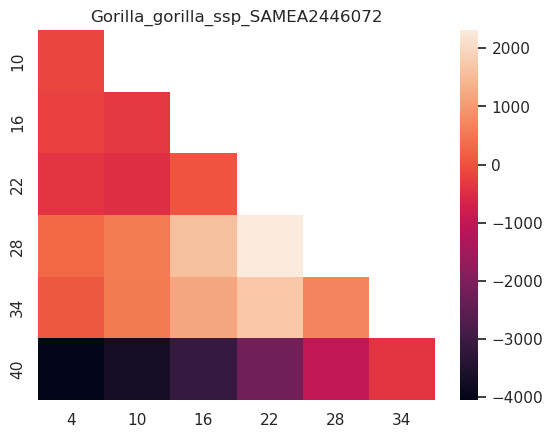

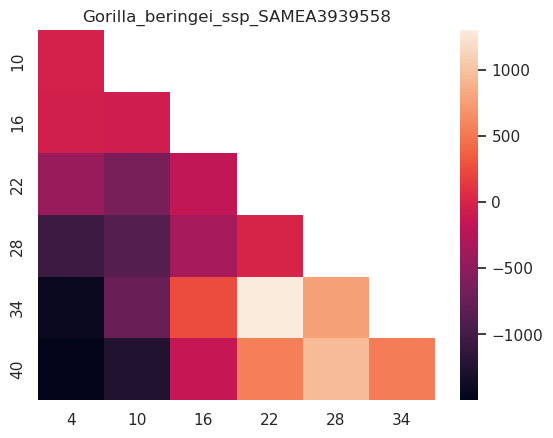

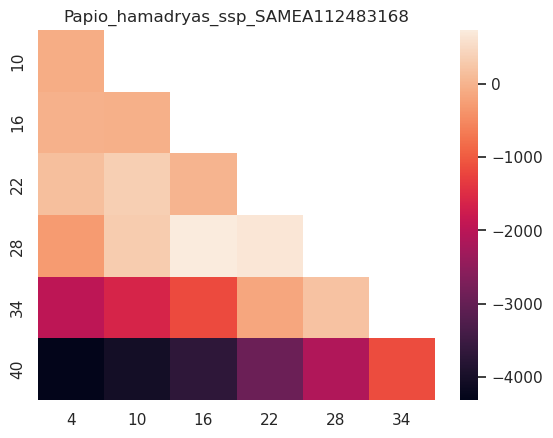

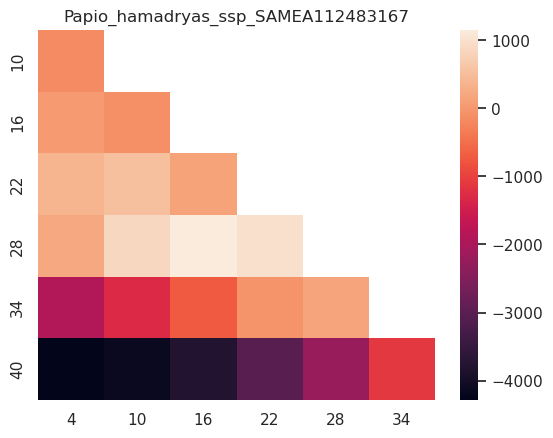

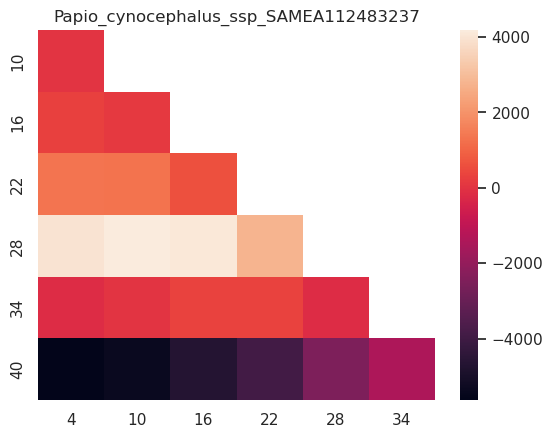

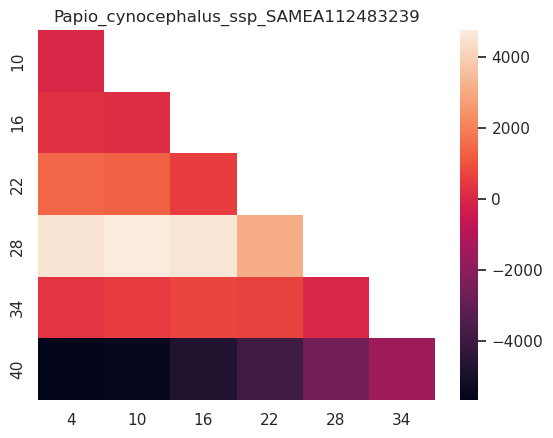

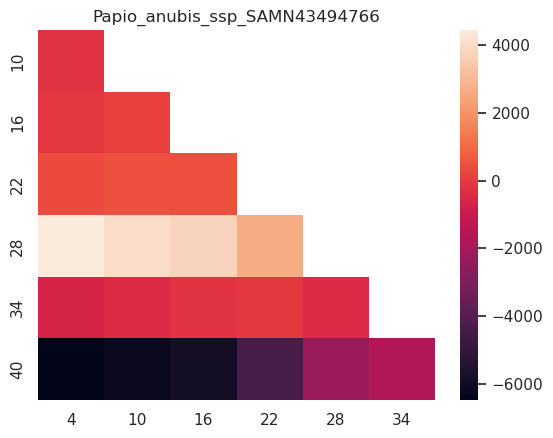

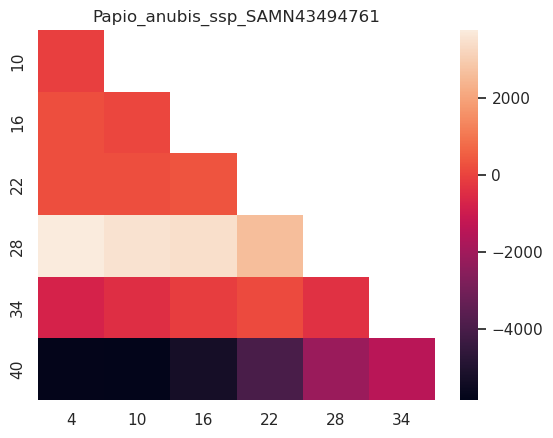

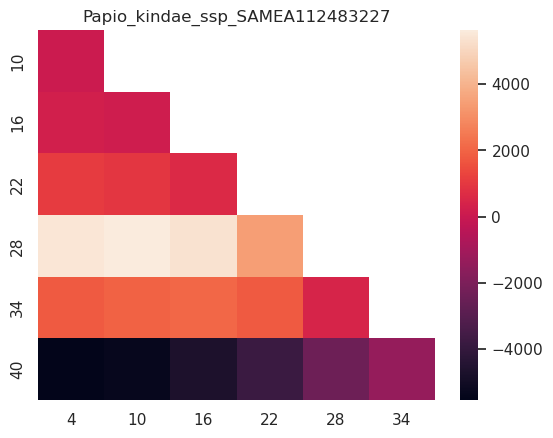

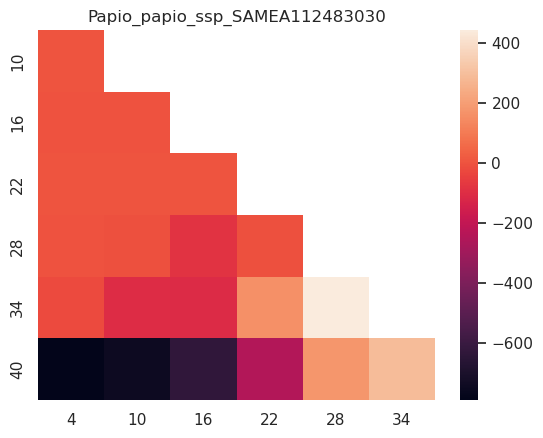

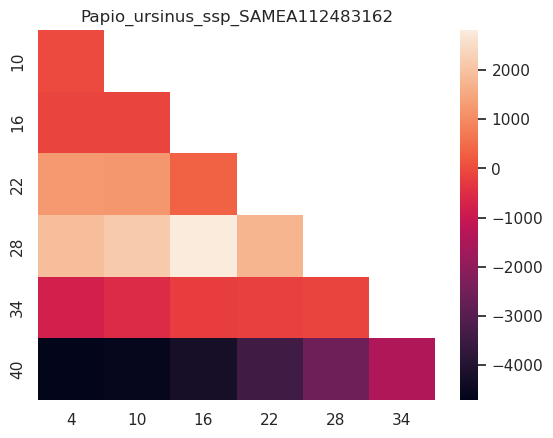

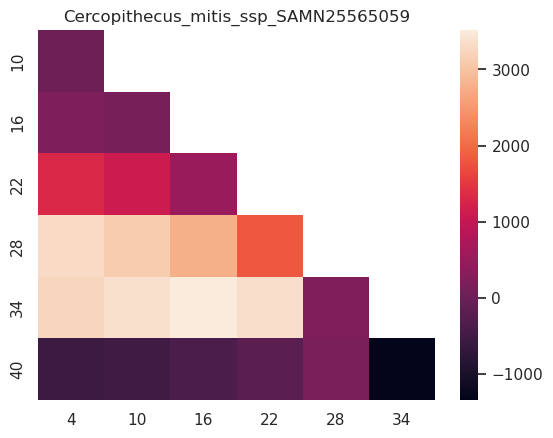

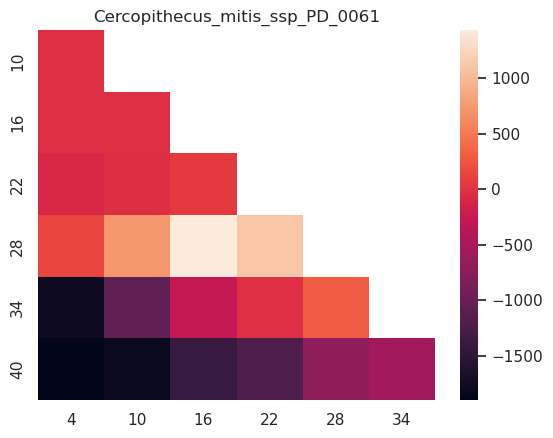

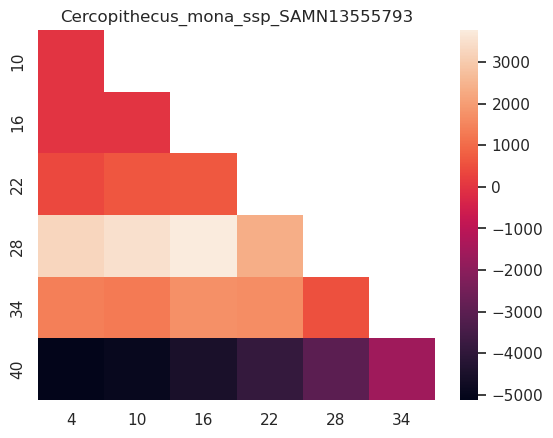

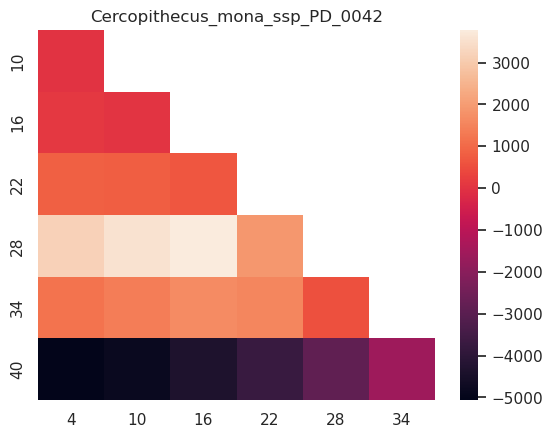

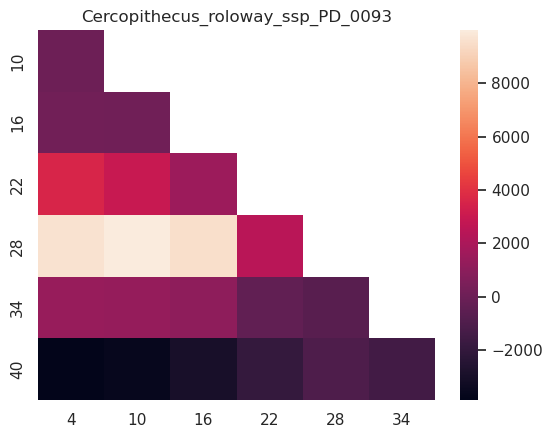

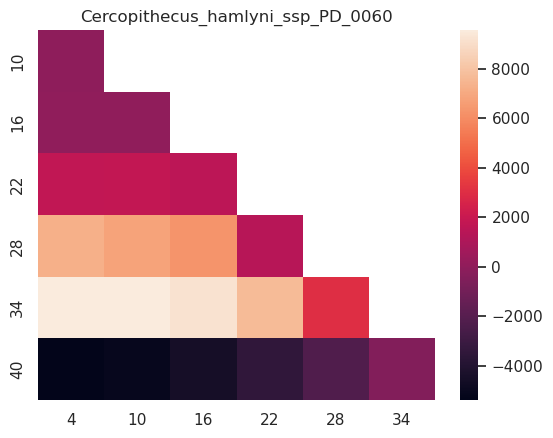

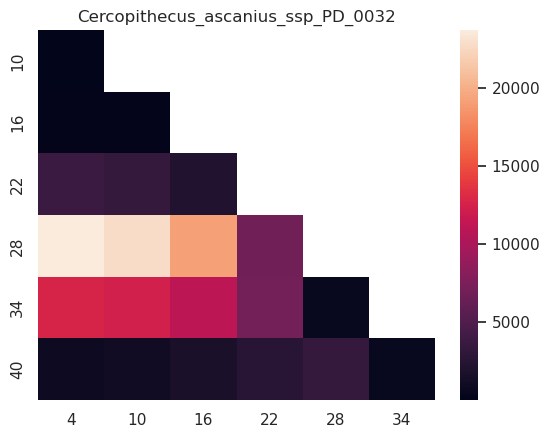

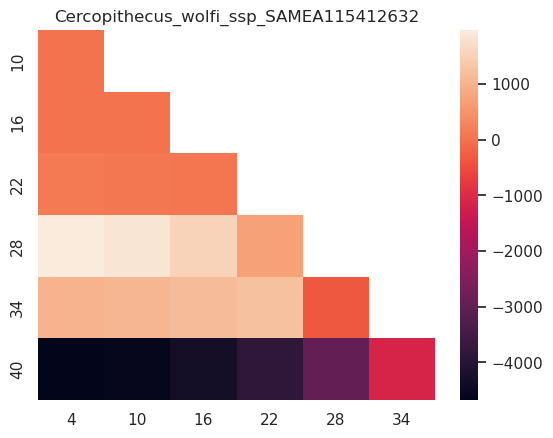

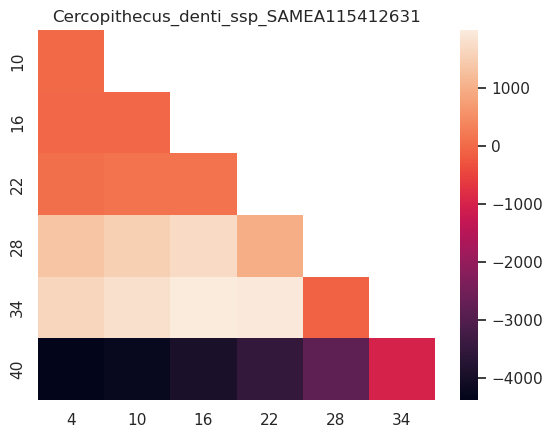

<Figure size 640x480 with 0 Axes>

In [10]:
for d in metadata_dirs[:]:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    dir_metadata["gss"] = dir_metadata.GENUS+"_"+dir_metadata.SPECIES+"_"+dir_metadata.SUBSPECIES
    short_species = d.split("/")[-1].split("_")[0]
    female_df = dir_metadata[pd.to_numeric(dir_metadata['AVG_COVERAGE_X'], errors='coerce').notnull()]
    female_df = female_df.loc[(female_df.GENETIC_SEX == "F") & (female_df.AVG_COVERAGE_A >= 10)].sort_values(by="AVG_COVERAGE_A", ascending=False)
    sorted_df = female_df
    # Go through every unique genotype calling set.
    for gvcf_folder in sorted_df.GVCF_FOLDER.unique():
        print(gvcf_folder)
        # Pick all inds that are present in the cobraa analysis.
        species_df = sorted_df.loc[sorted_df.GVCF_ID.isin(ind_list) & (sorted_df.GVCF_FOLDER == gvcf_folder)]
        for ind in species_df.GVCF_ID:
            final_params_file_pan = f'../steps/cobraa/{ind}/aut_final_parameters.txt'
            pan_LL = get_LL_from_file(final_params_file_pan)
            matrix_LL_diffs = np.zeros(shape=(6,6))
            matrix_LL_diffs[:] = np.nan
            for te in range(10, 42, 6):
                for ts in range(4, te-4, 6):
                    final_params_file_struct = f'../steps/cobraa/{ind}/aut_D50_ts{ts}_te{te}_final_parameters.txt'
                    struct_LL = get_LL_from_file(final_params_file_struct)
                    diff_LL = struct_LL - pan_LL
                    matrix_LL_diffs[int((te-6)/6),int(ts/6)] = diff_LL
            matrix_LL_diffs = matrix_LL_diffs
            print(ind, pan_LL, np.nanmax(matrix_LL_diffs))
            g = sns.heatmap(matrix_LL_diffs)
            g.set(xticklabels=list(range(4, te-4, 6)), yticklabels=list(range(10, 42, 6)),title=gvcf_folder+"_"+ind)
            plt.figure()

In [12]:
def find_best(file_list):
    best_param_file = None
    best_val = None
    # Go through the files and pick the 
    for p in file_list:
        LL = get_LL_from_file(p)
        if best_val == None:
            best_val = LL
            best_param_file = p
        if best_val < LL:
            best_val = LL
            best_param_file = p

    with open(best_param_file) as f:
        finallines = f.readlines()
    ztheta = float([i for i in finallines if 'theta' in i ][0].split(' ')[-1])
    zrho = float([i for i in finallines if 'rho' in i ][0].split(' ')[-1])
    zgamma = float([i for i in finallines if 'gamma' in i ][0].split(' ')[-1])
    file_name = best_param_file.split("/")[-1]
    zte = int(file_name.split("te")[1].split("_")[0])
    zts = int(file_name.split("ts")[1].split("_")[0])
    
    final_params = np.loadtxt(best_param_file)
    lambdaA_parameters = ",".join([str(x) for x in final_params[:,2]*ztheta/4])
    lambdaB_parameters = ",".join([str(x) for x in final_params[:,3]*ztheta/4])
    return zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file

Gorilla_gorilla_ssp
28 22 0.40601336727431236 ../steps/cobraa/SAMEA2446072/aut_D50_ts22_te28_final_parameters.txt
1.33e-08 22.0
Gorilla_beringei_ssp
34 22 0.41645186149817737 ../steps/cobraa/SAMEA3939558/aut_D50_ts22_te34_final_parameters.txt
1.2e-08 20.0
Papio_hamadryas_ssp
28 16 0.2855779807275157 ../steps/cobraa/SAMEA112483168/aut_D50_ts16_te28_final_parameters.txt
6.08e-09 15.0
28 16 0.2664432365613792 ../steps/cobraa/SAMEA112483167/aut_D50_ts16_te28_final_parameters.txt
6.08e-09 15.0
Papio_cynocephalus_ssp
28 10 0.3165423122822582 ../steps/cobraa/SAMEA112483237/aut_D50_ts10_te28_final_parameters.txt
5.88e-09 17.0
28 10 0.31454980768889174 ../steps/cobraa/SAMEA112483239/aut_D50_ts10_te28_final_parameters.txt
5.88e-09 17.0
Papio_anubis_ssp
28 4 0.2608795217081541 ../steps/cobraa/SAMN43494766/aut_D50_ts4_te28_final_parameters.txt
3.91e-09 11.0
28 4 0.2786448013943805 ../steps/cobraa/SAMN43494761/aut_D50_ts4_te28_final_parameters.txt
3.91e-09 11.0
Papio_kindae_ssp
28 10 0.339356836488

/tmp/37288061/ipykernel_3223718/4067428385.py:62: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


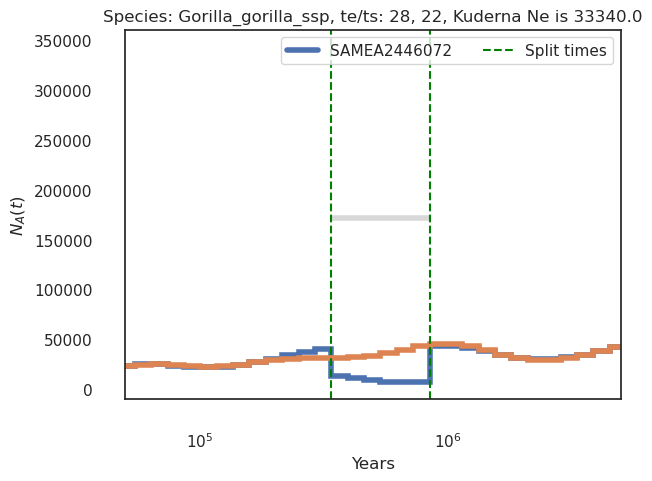

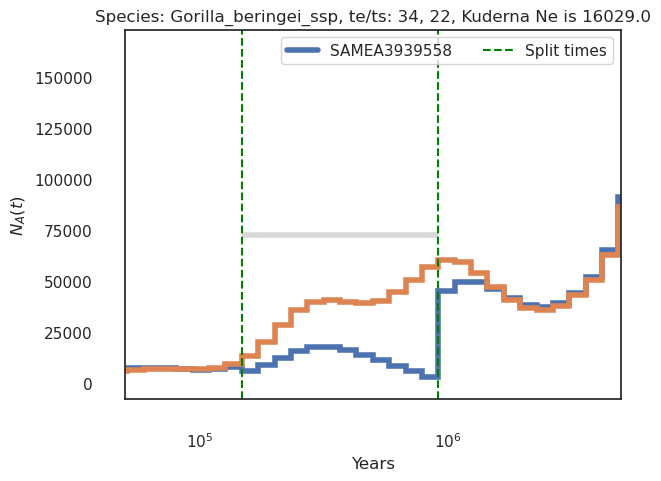

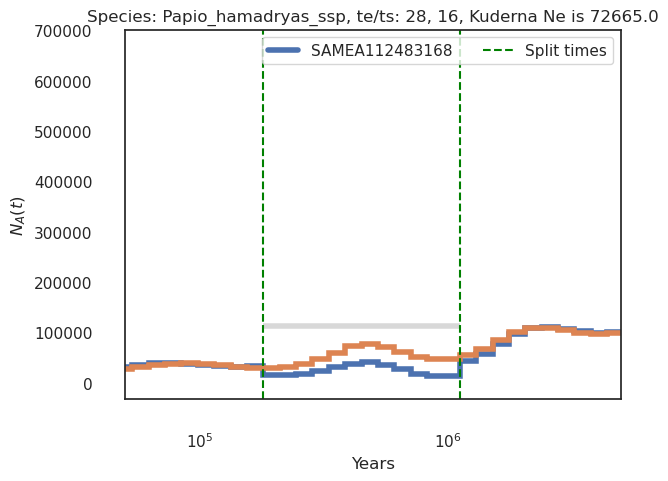

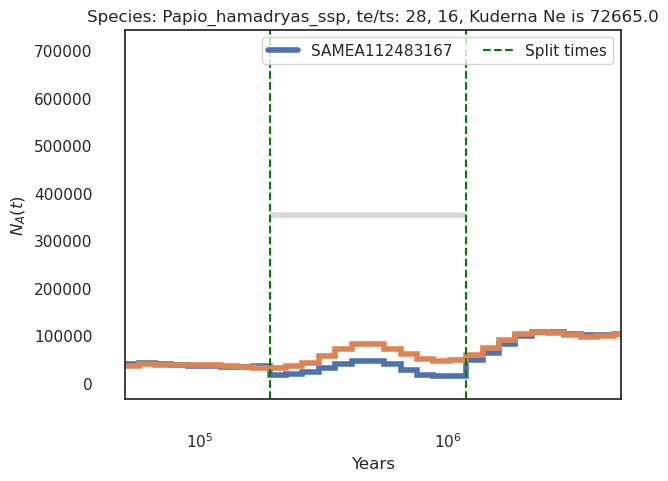

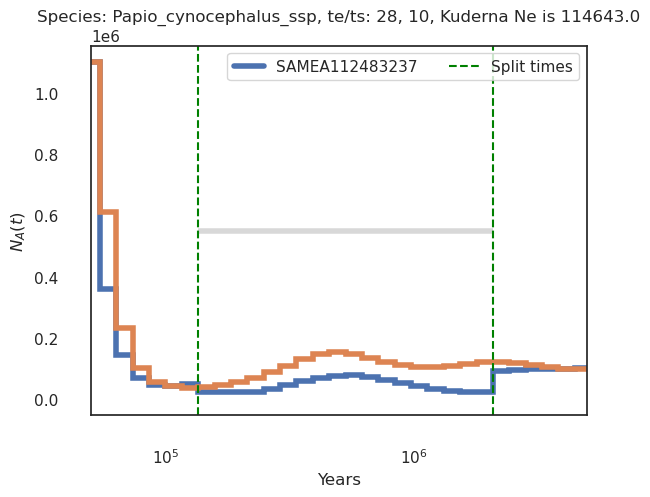

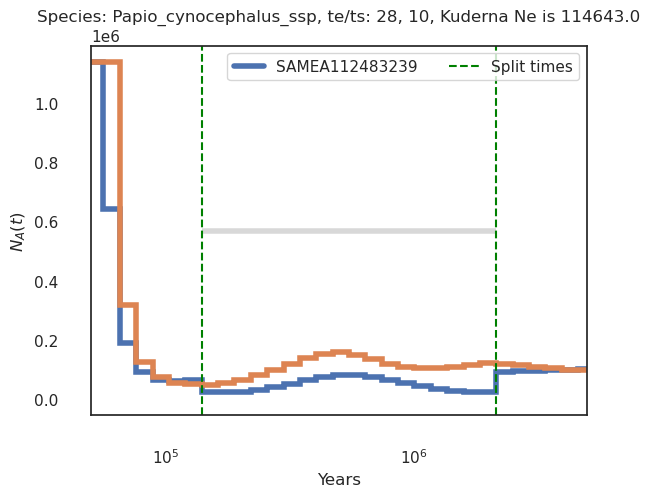

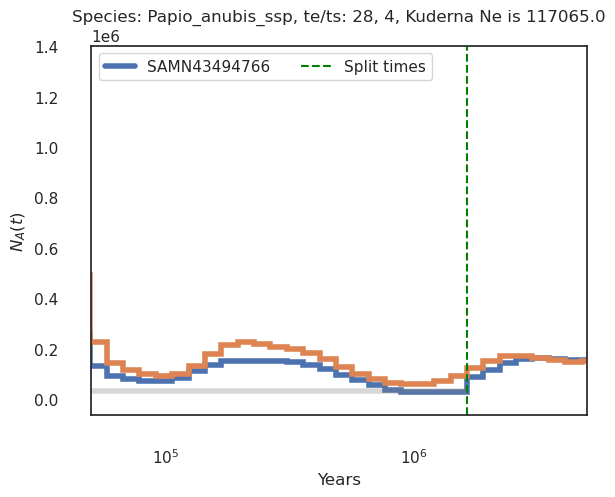

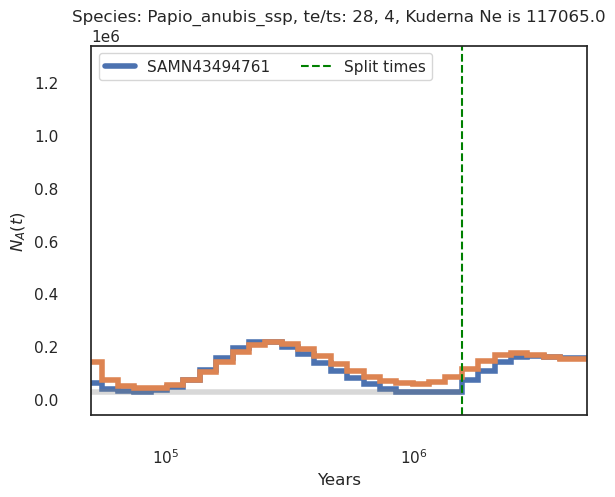

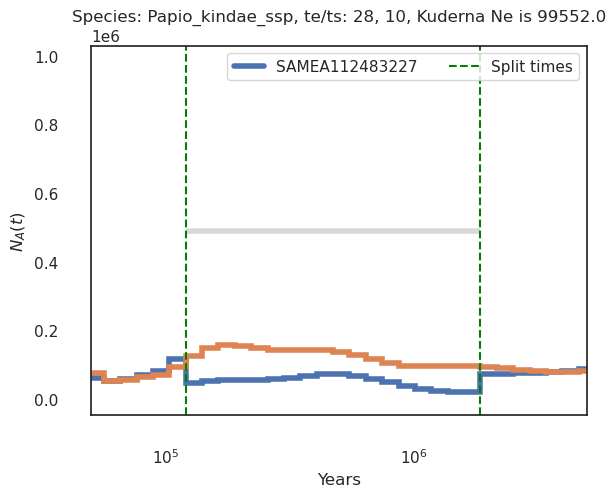

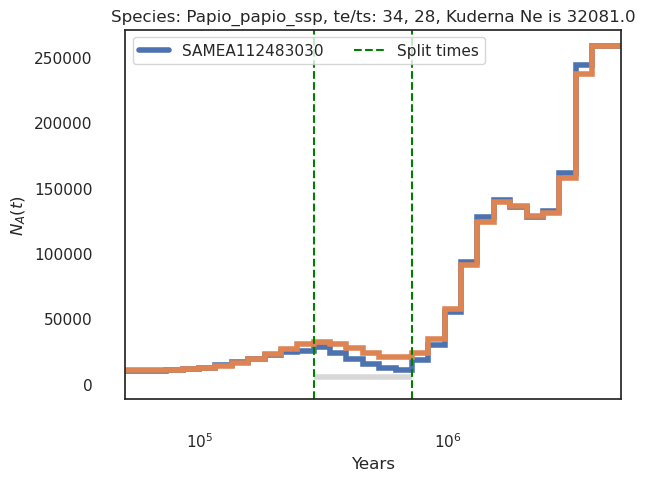

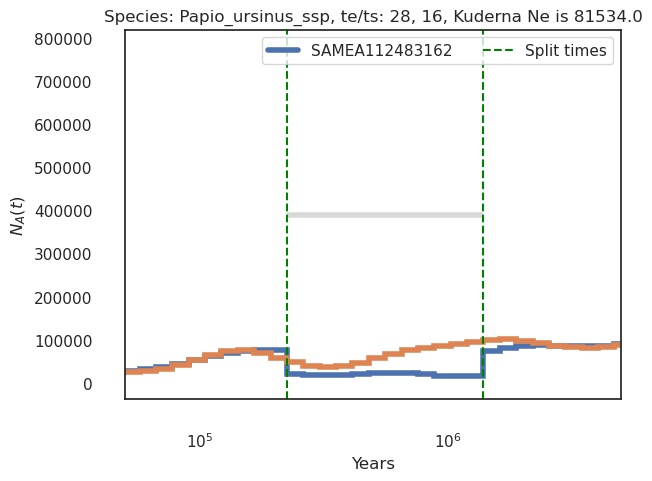

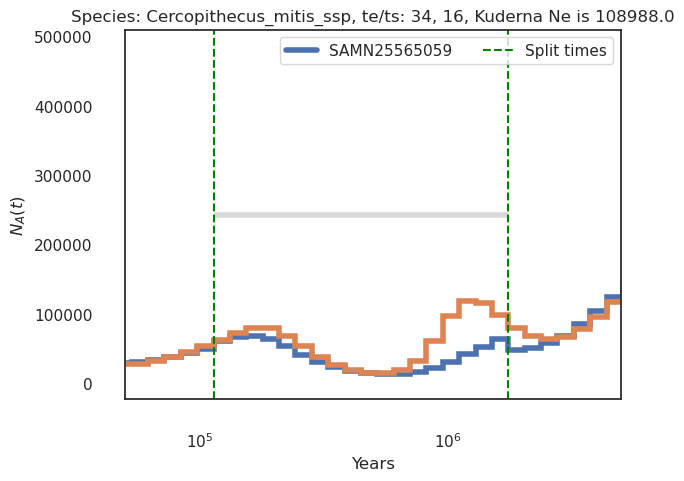

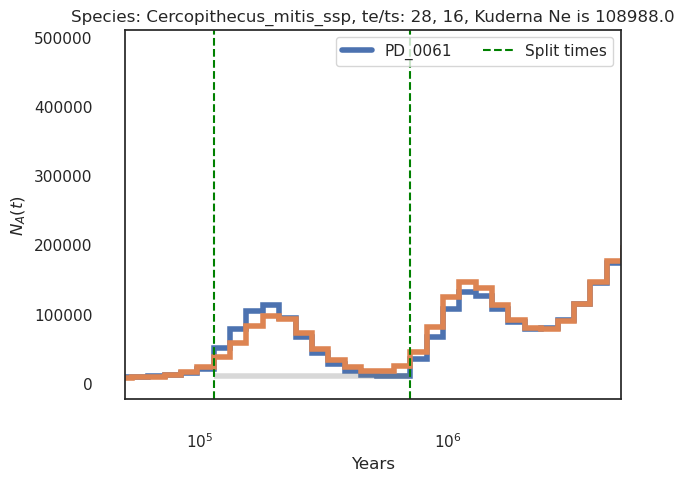

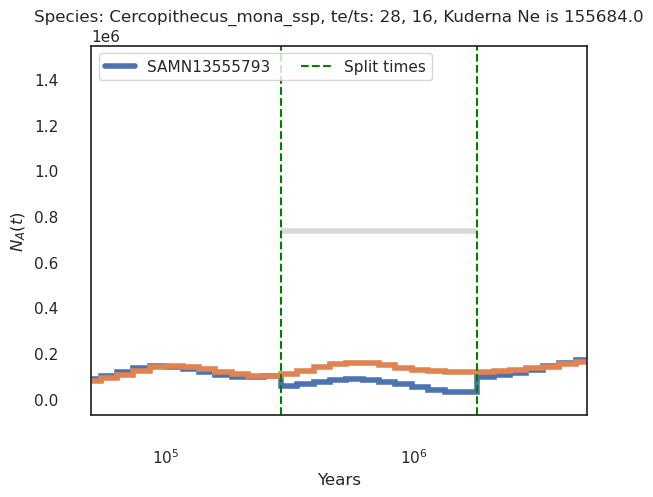

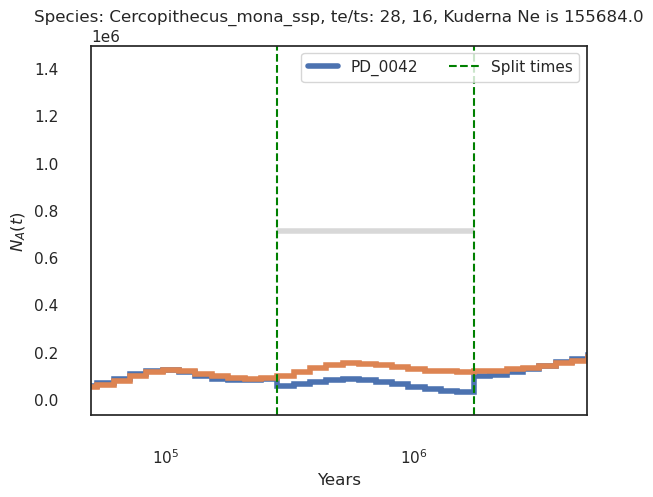

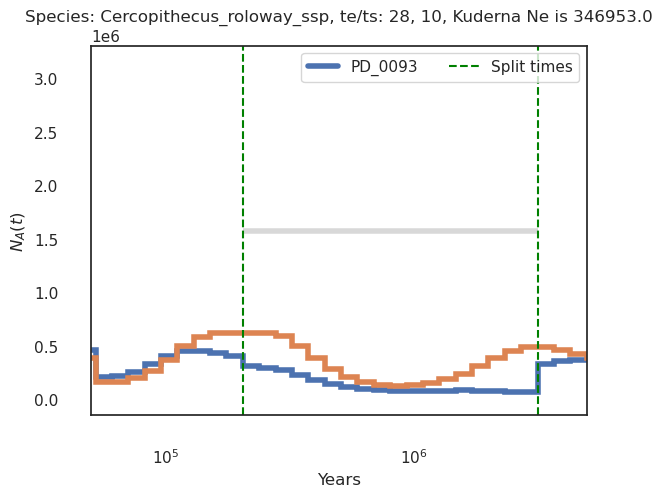

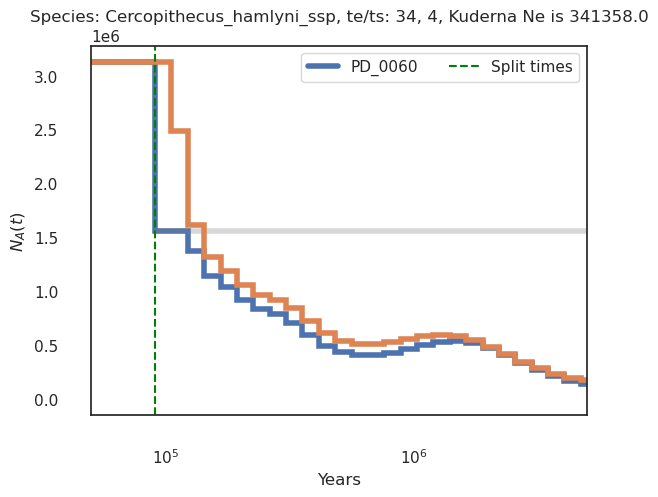

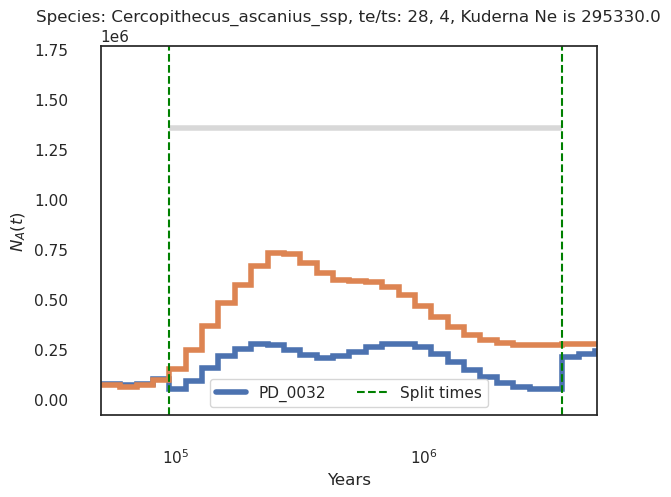

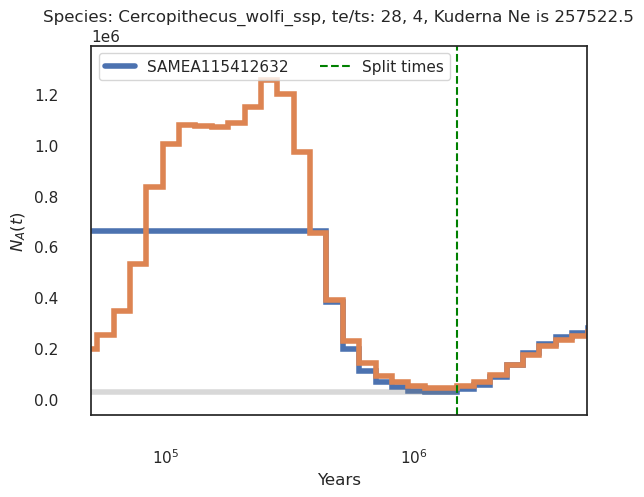

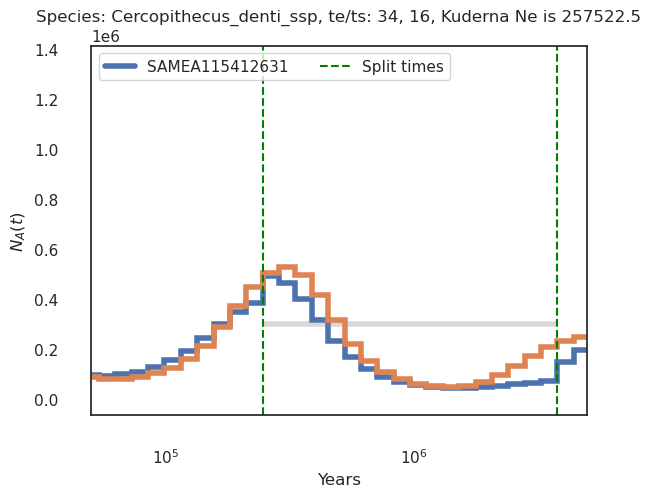

<Figure size 640x480 with 0 Axes>

In [13]:
for d in metadata_dirs:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    dir_metadata["gss"] = dir_metadata.GENUS+"_"+dir_metadata.SPECIES+"_"+dir_metadata.SUBSPECIES
    short_species = d.split("/")[-1].split("_")[0]
    female_df = dir_metadata[pd.to_numeric(dir_metadata['AVG_COVERAGE_X'], errors='coerce').notnull()]
    female_df = female_df.loc[(female_df.GENETIC_SEX == "F") & (female_df.AVG_COVERAGE_A >= 10)].sort_values(by="AVG_COVERAGE_A", ascending=False)
    sorted_df = female_df
    # Go through every unique genotype calling set.
    for gvcf_folder in sorted_df.GVCF_FOLDER.unique():
        print(gvcf_folder)
        # Pick all inds that are present in the cobraa analysis.
        species_df = sorted_df.loc[sorted_df.GVCF_ID.isin(ind_list) & (sorted_df.GVCF_FOLDER == gvcf_folder)]
        for ind in species_df.GVCF_ID:
            structured_files = glob.glob(f'../steps/cobraa/{ind}/aut_D50_ts*_te*_final_parameters.txt')
            zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
            label_tag = best_param_file.split("/")[-2]
            print(zte, zts, zgamma, best_param_file)
            ind_inf = all_inds.loc[all_inds.GVCF_ID == label_tag]
            gs = ind_inf.GENUS.iloc[0]+"_"+ind_inf.SPECIES.iloc[0]
            gs_df = df_species_mut.loc[df_species_mut.SPECIES_BINOMIAL == gs]
            g_df = df_species_mut.loc[df_species_mut.GENUS == ind_inf.GENUS.iloc[0]] 
            if len(gs_df) > 0:
                mu = gs_df.MU_PER_GENERATION.mean()
                gen = gs_df.GENERATION_LENGTH.mean()
                kuderna_Ne = gs_df.EFFECTIVE_POP_SIZE.mean()
            elif len(g_df) > 0:
                mu = g_df.MU_PER_GENERATION.mean()
                gen = g_df.GENERATION_LENGTH.mean()
                kuderna_Ne = g_df.EFFECTIVE_POP_SIZE.mean()
            print(mu, gen)
            final_params = np.loadtxt(best_param_file)
            time_array = list(final_params[:,1])
            time_array.insert(0,0)
            time_array = np.array(time_array)
            plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
            plt.stairs(edges=(time_array[zts:zte+1]/mu)*gen,values=(1/final_params[zts:zte,3])/mu,label='',linewidth=4,linestyle="solid",baseline=None,color="grey",alpha=0.3)
            plt.axvline((time_array[zts]/mu)*gen,color="green",linestyle="dashed")  
            plt.axvline((time_array[zte]/mu)*gen,label="Split times",color="green",linestyle="dashed")    
            plt.xlim(5e+04,5e+06)
            #plt.ylim(0,20e+04)
            plt.xscale('log')
            plt.ylabel('$N_A(t)$')
            plt.xlabel('Years')
            plt.tick_params(which='major',length=20)
            plt.tick_params(which='minor',length=10)
            plt.legend(ncol=2)
            # Unstructured for comp
            final_params = np.loadtxt(f'../steps/cobraa/{ind}/aut_final_parameters.txt')
            time_array = list(final_params[:,1])
            time_array.insert(0,0)
            time_array = np.array(time_array)
            plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
            plt.xlim(5e+04,5e+06)
            #plt.ylim(0,20e+04)
            plt.xscale('log')
            plt.ylabel('$N_A(t)$')
            plt.xlabel('Years')
            plt.tick_params(which='major',length=20)
            plt.tick_params(which='minor',length=10)
            plt.title("Species: {}, te/ts: {}, {}, Kuderna Ne is {}".format(gvcf_folder, zte, zts, kuderna_Ne))
            plt.figure()

Gorilla_gorilla_ssp
28 22 0.3423120846962198 ../steps/cobraa/SAMEA2446072/chrX_D50_ts22_te28_final_parameters.txt
1.0640000000000001e-08 22.0
28 16 0.30155462014718826 ../steps/cobraa/SAMN35877944/chrX_D50_ts16_te28_final_parameters.txt
1.0640000000000001e-08 22.0
Gorilla_beringei_ssp
34 22 0.34550426045478483 ../steps/cobraa/SAMEA3939558/chrX_D50_ts22_te34_final_parameters.txt
9.6e-09 20.0
34 22 0.3371243842832248 ../steps/cobraa/SAMEA3939556/chrX_D50_ts22_te34_final_parameters.txt
9.6e-09 20.0
Papio_hamadryas_ssp
28 16 0.33206550361186865 ../steps/cobraa/SAMEA112483168/chrX_D50_ts16_te28_final_parameters.txt
4.864e-09 15.0
28 10 0.4879616134253101 ../steps/cobraa/SAMEA112483167/chrX_D50_ts10_te28_final_parameters.txt
4.864e-09 15.0
Papio_cynocephalus_ssp
34 22 0.22760898211315875 ../steps/cobraa/SAMEA112483237/chrX_D50_ts22_te34_final_parameters.txt
4.704e-09 17.0
34 22 0.21746805903169705 ../steps/cobraa/SAMEA112483239/chrX_D50_ts22_te34_final_parameters.txt
4.704e-09 17.0
34 22 0.3

/tmp/11354112/ipykernel_3432454/2274502292.py:62: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


28 16 0.3437916263853954 ../steps/cobraa/SAMN13555793/chrX_D50_ts16_te28_final_parameters.txt
4.488e-09 11.0
28 16 0.33037328052666115 ../steps/cobraa/PD_0042/chrX_D50_ts16_te28_final_parameters.txt
4.488e-09 11.0
Cercopithecus_roloway_ssp
28 10 0.1806582619999729 ../steps/cobraa/PD_0093/chrX_D50_ts10_te28_final_parameters.txt
2.664e-09 9.0
Cercopithecus_hamlyni_ssp
28 4 0.4228218136121492 ../steps/cobraa/PD_0060/chrX_D50_ts4_te28_final_parameters.txt
2.816e-09 10.0
Cercopithecus_ascanius_ssp
34 10 0.1466762991493601 ../steps/cobraa/PD_0032/chrX_D50_ts10_te34_final_parameters.txt
4.832e-09 12.0
34 10 0.14459650968045631 ../steps/cobraa/PD_0066/chrX_D50_ts10_te34_final_parameters.txt
4.832e-09 12.0
Cercopithecus_wolfi_ssp
34 4 0.023638350430101818 ../steps/cobraa/SAMEA115412632/chrX_D50_ts4_te34_final_parameters.txt
3.883999999999999e-09 10.166666666666666
Cercopithecus_denti_ssp


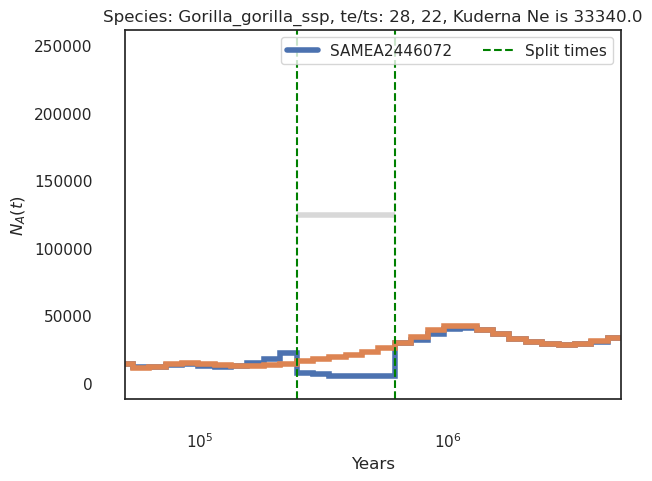

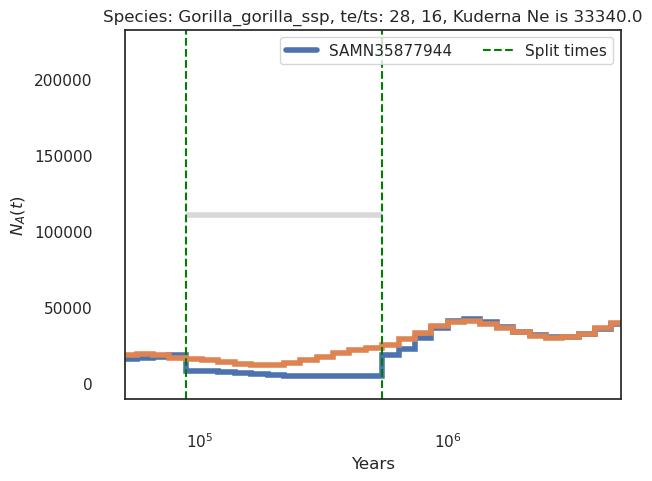

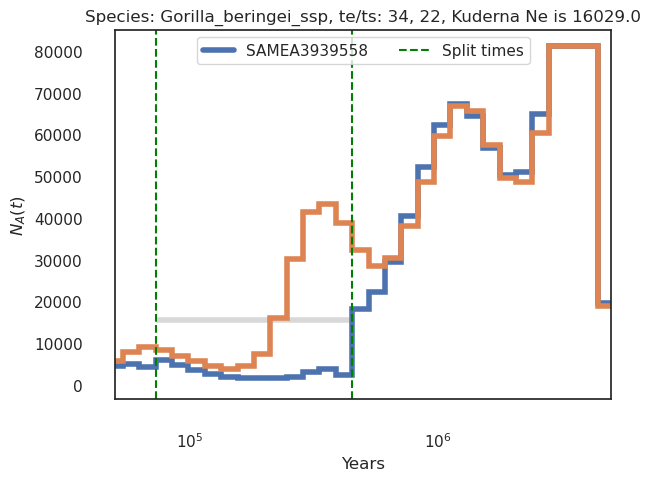

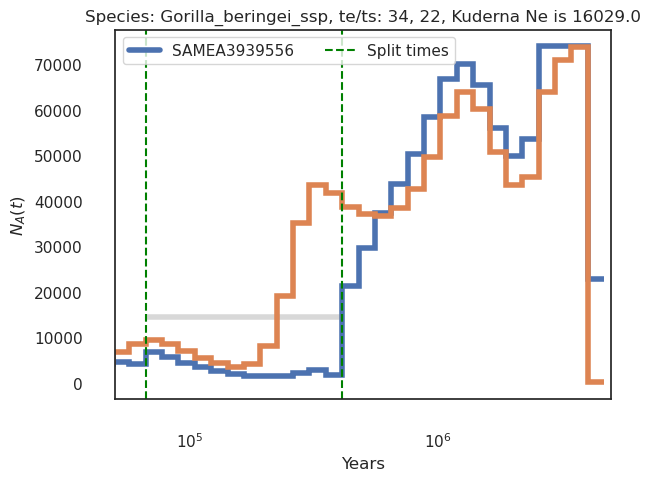

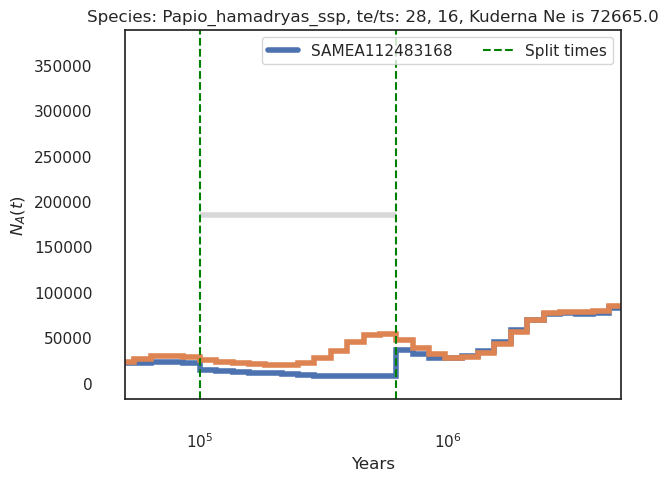

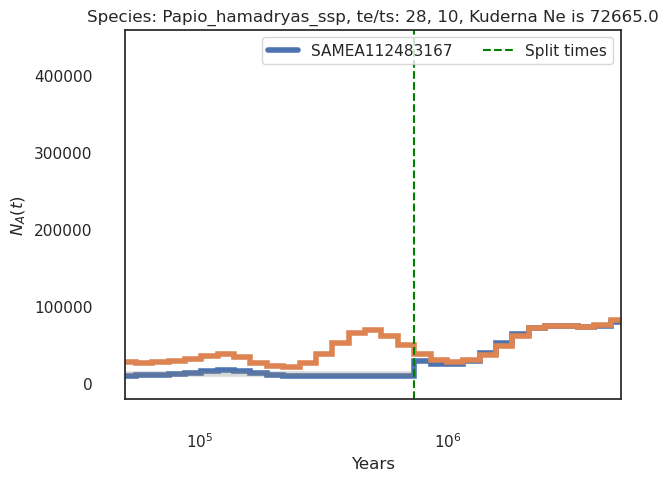

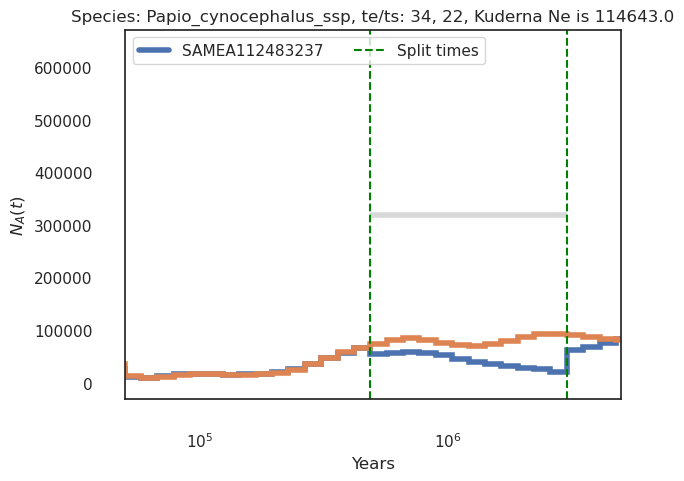

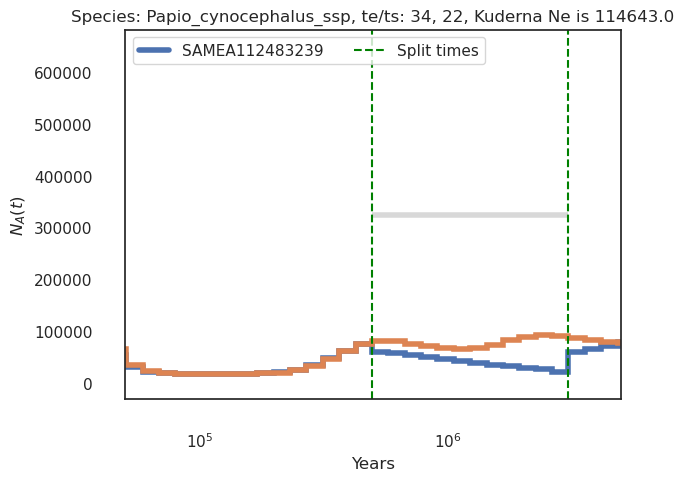

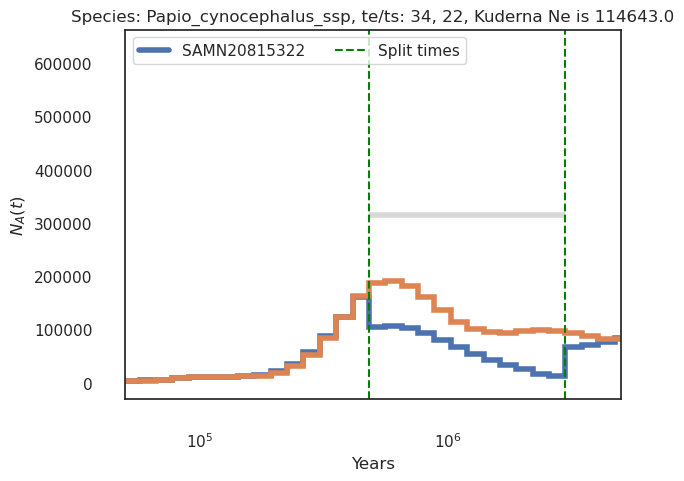

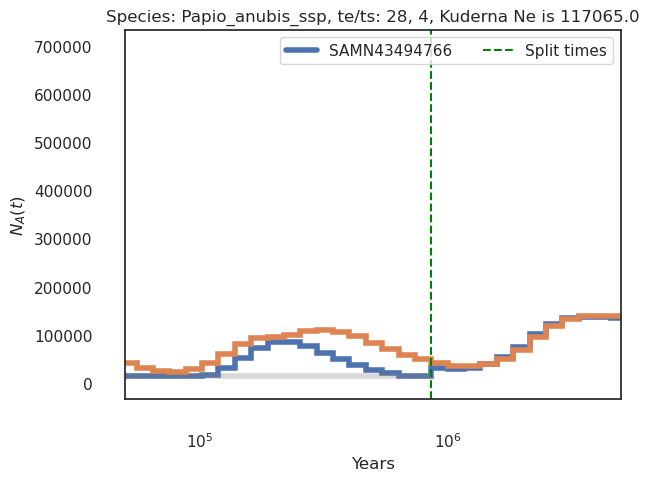

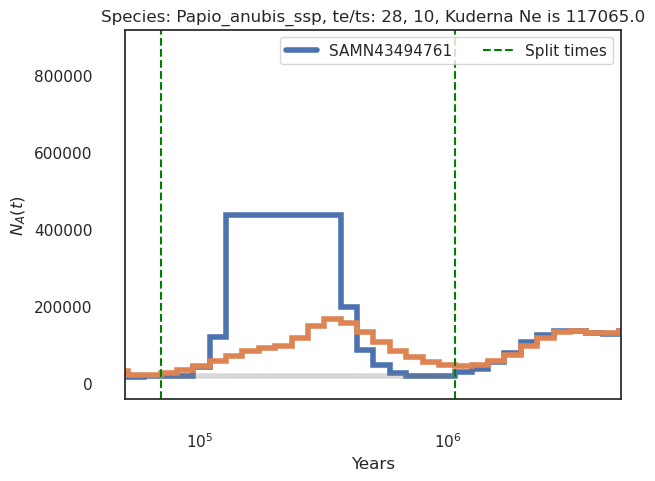

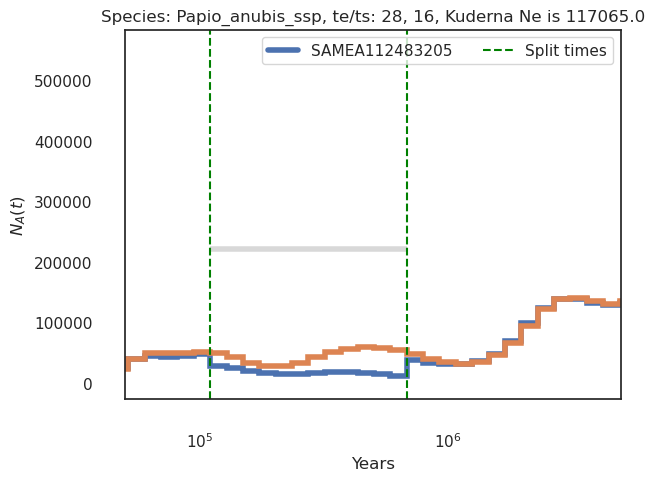

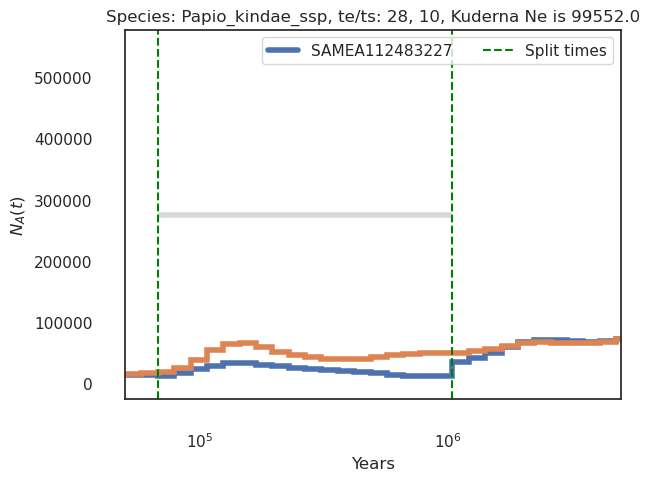

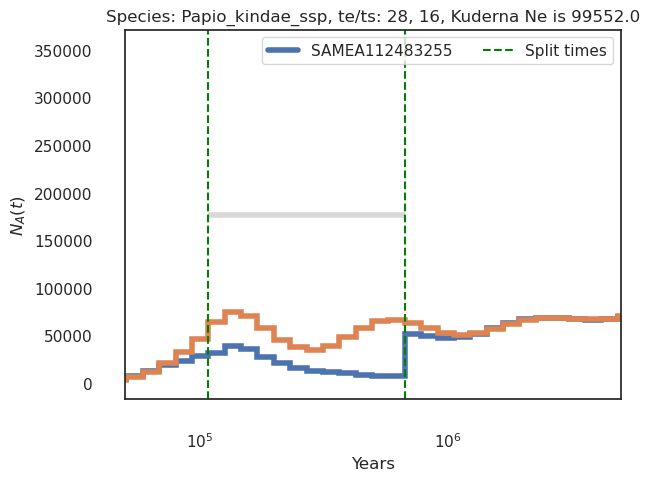

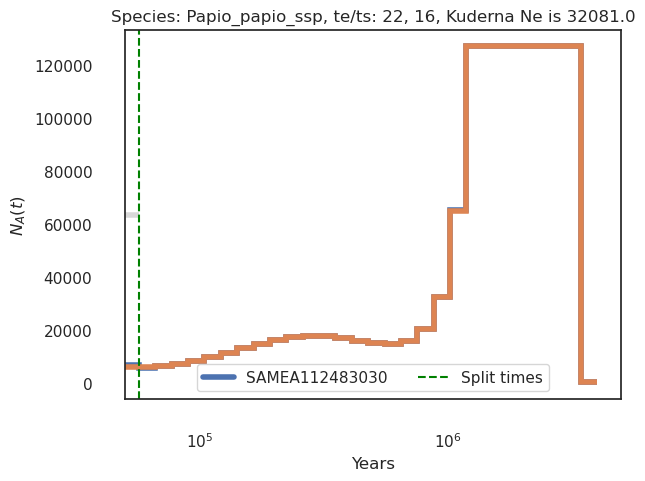

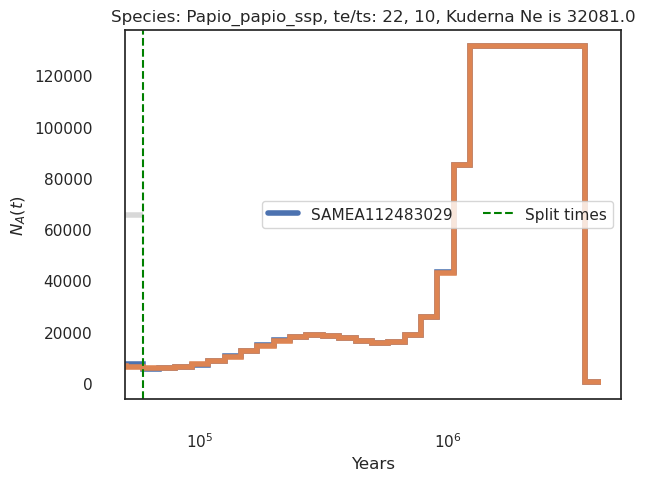

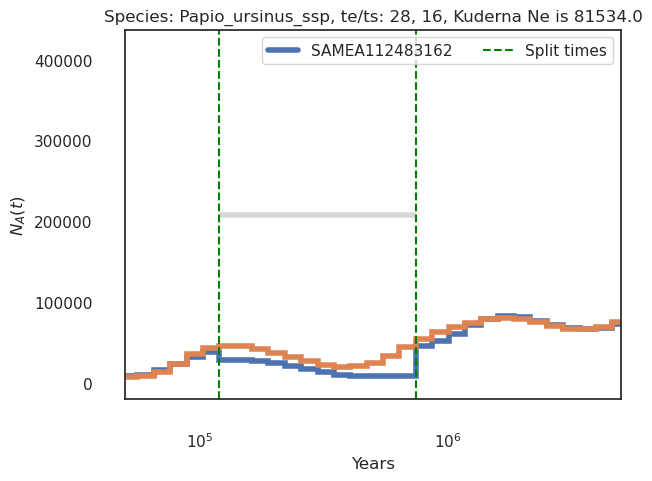

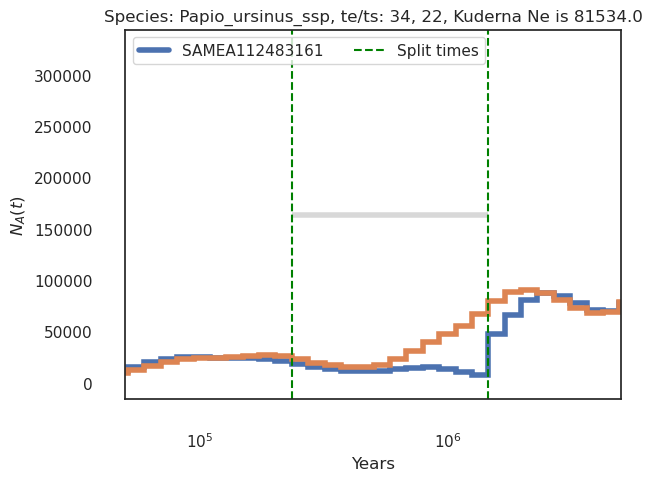

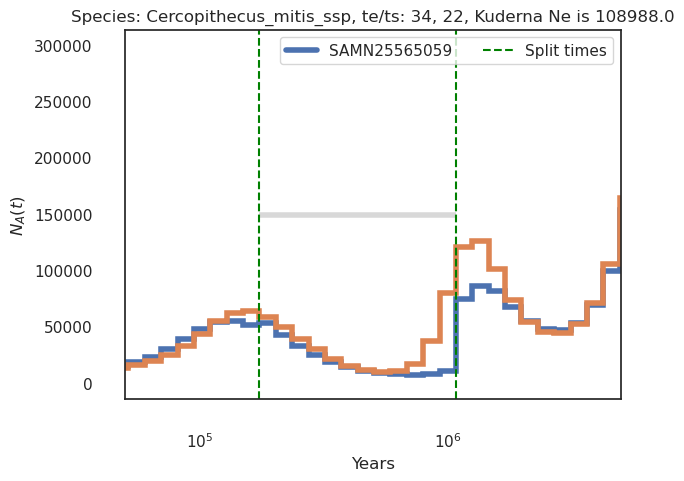

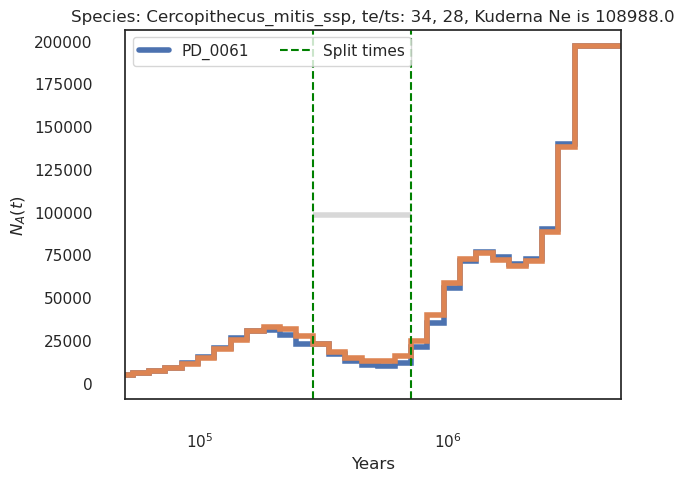

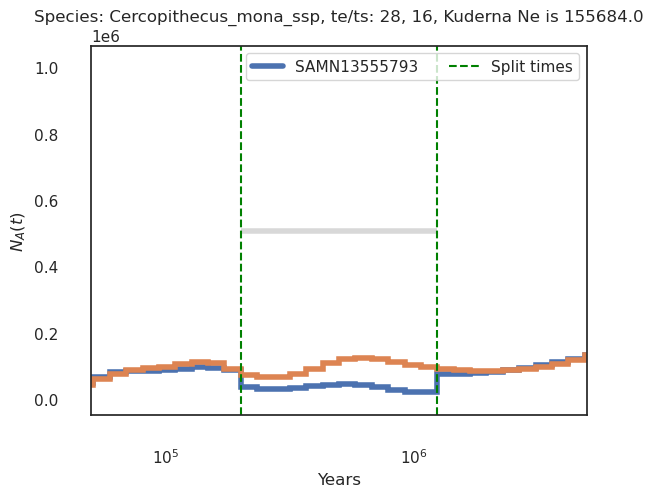

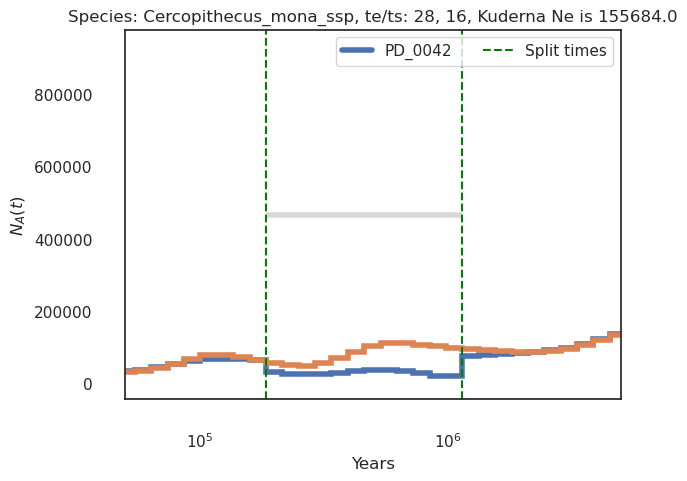

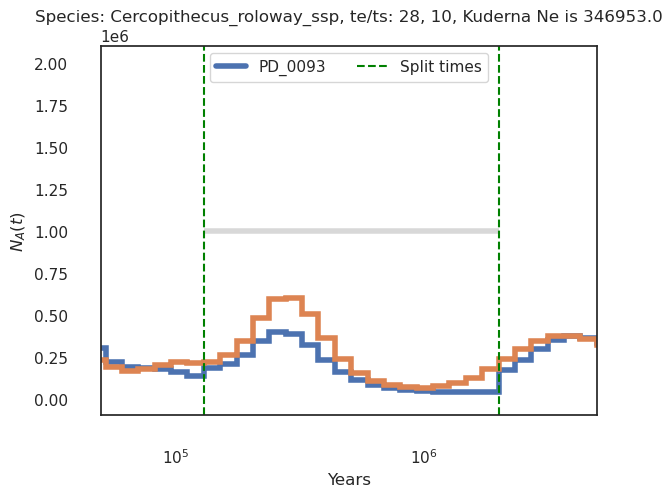

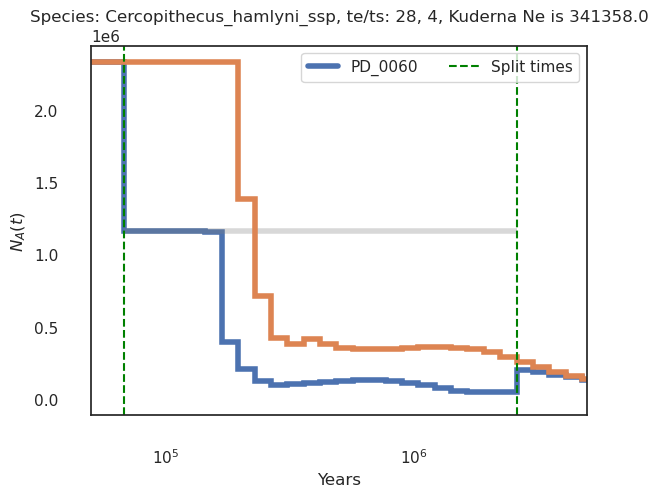

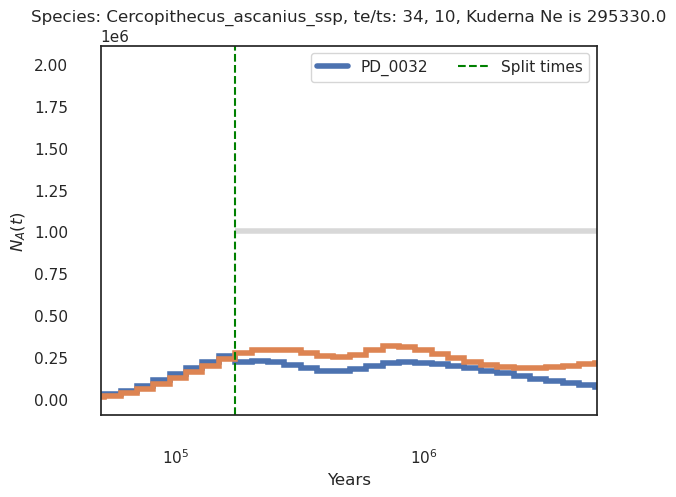

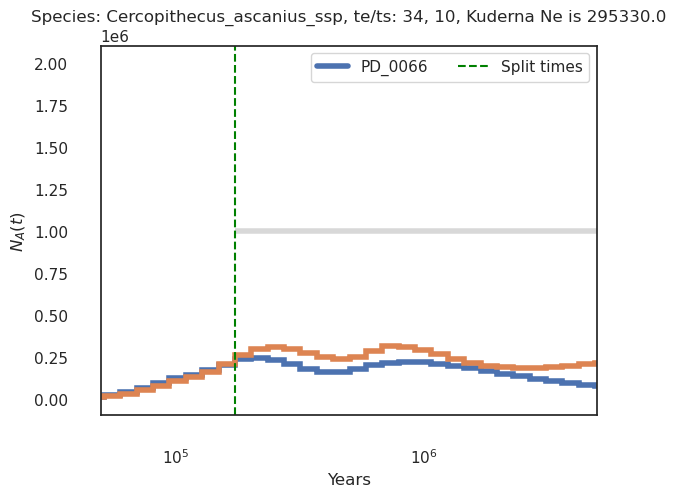

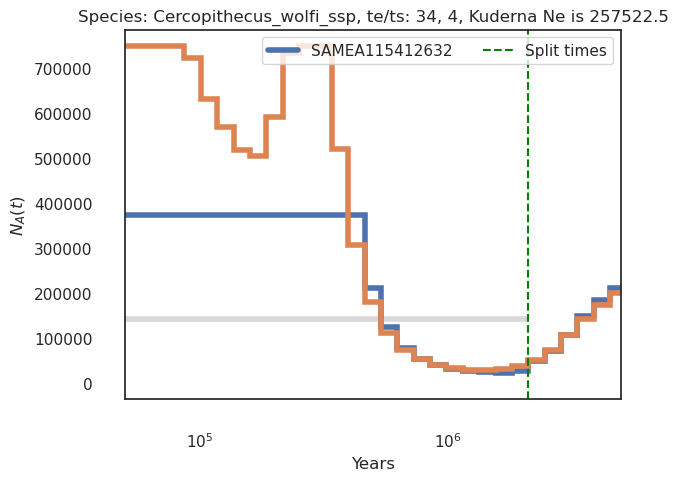

<Figure size 640x480 with 0 Axes>

In [16]:
for d in metadata_dirs:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    dir_metadata["gss"] = dir_metadata.GENUS+"_"+dir_metadata.SPECIES+"_"+dir_metadata.SUBSPECIES
    short_species = d.split("/")[-1].split("_")[0]
    female_df = dir_metadata[pd.to_numeric(dir_metadata['AVG_COVERAGE_X'], errors='coerce').notnull()]
    female_df = female_df.loc[(female_df.GENETIC_SEX == "F") & (female_df.AVG_COVERAGE_A >= 10)].sort_values(by="AVG_COVERAGE_A", ascending=False)
    sorted_df = female_df
    # Go through every unique genotype calling set.
    for gvcf_folder in sorted_df.GVCF_FOLDER.unique():
        print(gvcf_folder)
        # Pick all inds that are present in the cobraa analysis.
        species_df = sorted_df.loc[sorted_df.GVCF_ID.isin(ind_list) & (sorted_df.GVCF_FOLDER == gvcf_folder)]
        for ind in species_df.GVCF_ID:
            structured_files = glob.glob(f'../steps/cobraa/{ind}/chrX_D50_ts*_te*_final_parameters.txt')
            zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
            label_tag = best_param_file.split("/")[-2]
            print(zte, zts, zgamma, best_param_file)
            ind_inf = all_inds.loc[all_inds.GVCF_ID == label_tag]
            gs = ind_inf.GENUS.iloc[0]+"_"+ind_inf.SPECIES.iloc[0]
            gs_df = df_species_mut.loc[df_species_mut.SPECIES_BINOMIAL == gs]
            g_df = df_species_mut.loc[df_species_mut.GENUS == ind_inf.GENUS.iloc[0]] 
            if len(gs_df) > 0:
                mu = gs_df.MU_PER_GENERATION.mean()*0.8
                gen = gs_df.GENERATION_LENGTH.mean()
                kuderna_Ne = gs_df.EFFECTIVE_POP_SIZE.mean()
            elif len(g_df) > 0:
                mu = g_df.MU_PER_GENERATION.mean()*0.8
                gen = g_df.GENERATION_LENGTH.mean()
                kuderna_Ne = g_df.EFFECTIVE_POP_SIZE.mean()
            print(mu, gen)
            final_params = np.loadtxt(best_param_file)
            time_array = list(final_params[:,1])
            time_array.insert(0,0)
            time_array = np.array(time_array)
            plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
            plt.stairs(edges=(time_array[zts:zte+1]/mu)*gen,values=(1/final_params[zts:zte,3])/mu,label='',linewidth=4,linestyle="solid",baseline=None,color="grey",alpha=0.3)
            plt.axvline((time_array[zts]/mu)*gen,color="green",linestyle="dashed")  
            plt.axvline((time_array[zte]/mu)*gen,label="Split times",color="green",linestyle="dashed")    
            plt.xlim(5e+04,5e+06)
            #plt.ylim(0,20e+04)
            plt.xscale('log')
            plt.ylabel('$N_A(t)$')
            plt.xlabel('Years')
            plt.tick_params(which='major',length=20)
            plt.tick_params(which='minor',length=10)
            plt.legend(ncol=2)
            # Unstructured for comp
            final_params = np.loadtxt(f'../steps/cobraa/{ind}/chrX_final_parameters.txt')
            time_array = list(final_params[:,1])
            time_array.insert(0,0)
            time_array = np.array(time_array)
            plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
            plt.xlim(5e+04,5e+06)
            #plt.ylim(0,20e+04)
            plt.xscale('log')
            plt.ylabel('$N_A(t)$')
            plt.xlabel('Years')
            plt.tick_params(which='major',length=20)
            plt.tick_params(which='minor',length=10)
            plt.title("Species: {}, te/ts: {}, {}, Kuderna Ne is {}".format(gvcf_folder, zte, zts, kuderna_Ne))
            plt.figure()

I generally dislike the "look" of results for ts 4, so I should probably restrict it to searching in the ts8/te38 range or something like that.